In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [6]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [7]:
# x_train = x_train.astype("float32") / 255.0
# x_test = x_test.astype("float32") / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test , 10)

In [8]:
datagen = ImageDataGenerator(
    rescale=1./255,         # normalize images
    rotation_range=15,      # slight rotation
    width_shift_range=0.1,  # move image left-right
    height_shift_range=0.1, # move image up-down
    horizontal_flip=True,   # random flip
)

In [9]:
model = tf.keras.Sequential([
    Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu',padding='same'),
    MaxPooling2D(2,2),
    Conv2D(128,(3,3),activation='relu',padding='same'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])
model.compile(optimizer = 'adam',loss = 'categorical_crossentropy',metrics = ['accuracy'])
history = model.fit(
    datagen.flow(x_train, y_train,batch_size = 64),
    epochs=10,
    validation_data = (x_test / 255.0, y_test),
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - accuracy: 0.2835 - loss: 1.9228 - val_accuracy: 0.5334 - val_loss: 1.3100
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.4839 - loss: 1.4326 - val_accuracy: 0.6029 - val_loss: 1.1336
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.5552 - loss: 1.2577 - val_accuracy: 0.6545 - val_loss: 0.9892
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.5952 - loss: 1.1536 - val_accuracy: 0.6618 - val_loss: 0.9418
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.6192 - loss: 1.0877 - val_accuracy: 0.6836 - val_loss: 0.8842
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.6462 - loss: 1.0303 - val_accuracy: 0.7003 - val_loss: 0.8507
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.6525 - loss: 0.9896 - val_accuracy: 0.7188 - val_loss: 0.8047
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.6703 - loss: 0.9471 - 

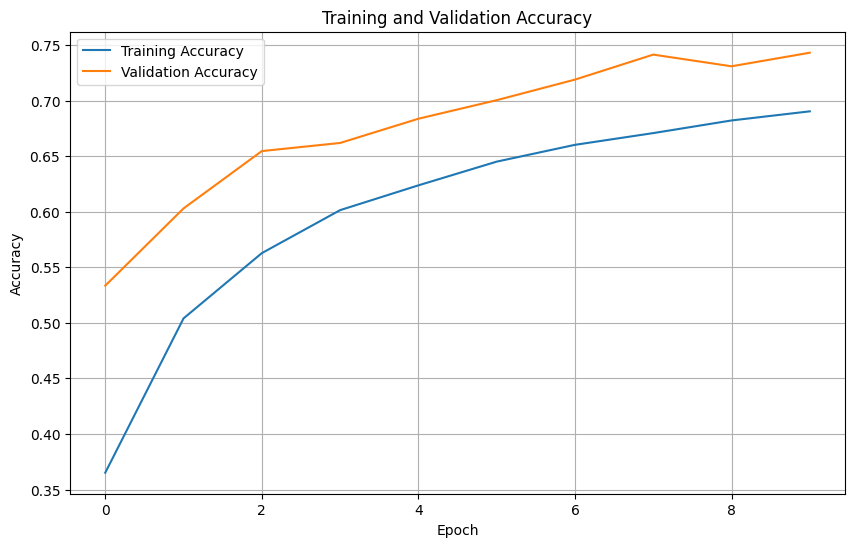

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()